In [ ]:
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
dataset=pd.read_csv("COVID.csv")

In [ ]:
dataset

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [ ]:
dataset.columns


Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [ ]:
data=dataset.drop(['Country/Region','Confirmed','Deaths','Recovered'], axis=1)

In [ ]:
X = dataset[['Confirmed','Deaths','Recovered']]

In [ ]:
y=dataset['Country/Region']

In [ ]:
dataset["Country/Region"].value_counts()

,count
Country/Region,
China,6204
Canada,2256
France,2068
United Kingdom,2068
Australia,1504
...,...
Sao Tome and Principe,188
Yemen,188
Comoros,188


In [ ]:
print(X.head())

   Confirmed  Deaths  Recovered
0          0       0          0
1          0       0          0
2          0       0          0
3          0       0          0
4          0       0          0


In [ ]:
print(y.tail())

49063    Sao Tome and Principe
49064                    Yemen
49065                  Comoros
49066               Tajikistan
49067                  Lesotho
Name: Country/Region, dtype: object


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


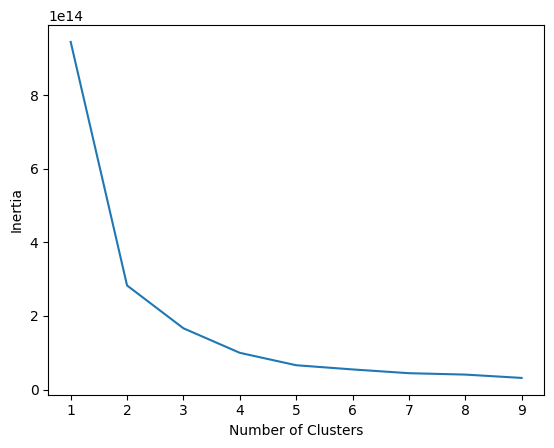

In [ ]:
from sklearn.cluster import KMeans
KGF=[]
for i in range(1,10):
  model = KMeans(n_clusters=i)
  model.fit(X)
  KGF.append(model.inertia_)

plt.plot(range(1,10),KGF)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [ ]:
model = KMeans(n_clusters=3,random_state=0)
y_means=model.fit_predict(X)

In [ ]:
X=X.values

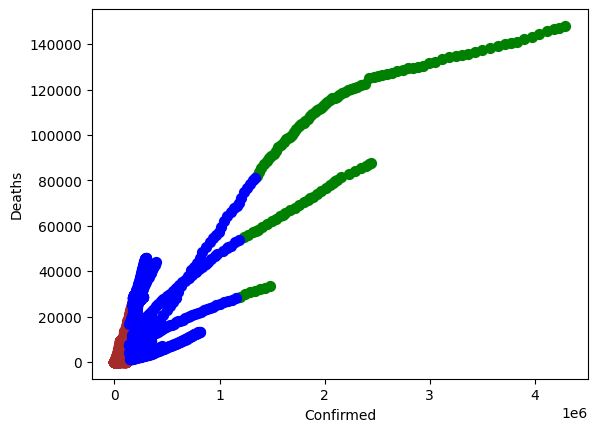

In [ ]:
plt.scatter(X[y_means==0,0],X[y_means==0,1],s=50,c="brown",label=1)
plt.scatter(X[y_means==1,0],X[y_means==1,1],s=50,c="green",label=1)
plt.scatter(X[y_means==2,0],X[y_means==2,1],s=50,c="blue",label=1)
plt.scatter(X[y_means==3,0],X[y_means==3,1],s=50,c="red",label=1)
plt.xlabel("Confirmed")
plt.ylabel("Deaths")
plt.show()